# Actividad 14 Aplicación Conceptos de GANs

Implementar una Red Generativa Adversaria (GAN) básica sobre el dataset MNIST para comprender el flujo técnico del entrenamiento adversarial.

**Dataset:** MNIST — 70 000 imágenes de dígitos escritos a mano (28×28 px, escala de grises).

## 1. GAN

Una **Red Generativa Adversaria (GAN)** es una arquitectura propuesta por Ian Goodfellow en 2014 formada por dos redes neuronales que compiten entre sí:

| Componente | Función | Entrada | Salida |
|---|---|---|---|
| **Generador (G)** | Crear muestras falsas que parezcan reales | Vector de ruido aleatorio `z` | Imagen sintética |
| **Discriminador (D)** | Distinguir imágenes reales de falsas | Imagen (real o generada) | Probabilidad de ser real |

### Dinámica adversarial

El entrenamiento funciona como un juego de suma cero:
- El **Generador** aprende a engañar al Discriminador produciendo imágenes cada vez más realistas.
- El **Discriminador** aprende a detectar imágenes falsas con mayor precisión.

Ambos mejoran simultáneamente hasta que el Generador produce imágenes indistinguibles de las reales (idealmente, el Discriminador responde 0.5 para cualquier imagen).

- El Discriminador **maximiza**: quiere asignar alta probabilidad a imágenes reales y baja a las generadas.
- El Generador **minimiza**: quiere que el Discriminador clasifique sus imágenes como reales.

## 0. Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Semilla para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.20.0
GPU disponible: True


## 2. Carga y preprocesamiento del dataset MNIST

Normalizamos los píxeles al rango **[-1, 1]** para que sean compatibles con la activación `tanh` del Generador.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape del dataset: (60000, 28, 28, 1)
Rango de valores: [-1.0, 1.0]


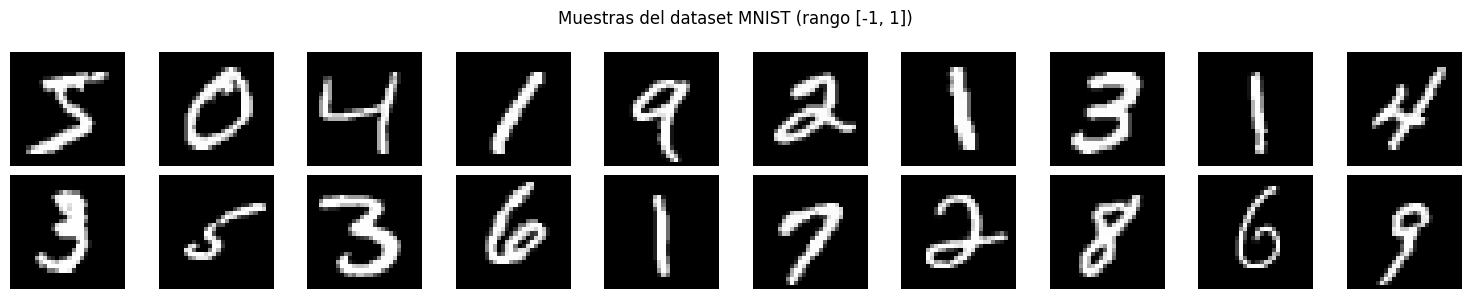

In [2]:
# Cargar MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Usar solo imágenes de entrenamiento
# Normalizar: [0, 255] → [-1, 1]
x_train = x_train.astype('float32') / 127.5 - 1.0

# Añadir dimensión de canal: (60000, 28, 28) → (60000, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)

print(f'Shape del dataset: {x_train.shape}')
print(f'Rango de valores: [{x_train.min():.1f}, {x_train.max():.1f}]')

# Visualizar muestras del dataset real
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Muestras del dataset MNIST (rango [-1, 1])', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Modelo Generador

El Generador transforma un vector de **ruido latente** en una imagen 28×28.

**Arquitectura:**
- Capa densa que expande el vector latente → tensor 7×7×256
- Tres bloques `Conv2DTranspose` (deconvolución) que hacen upsampling:
  - 7×7×256 → 7×7×128 → 14×14×64 → 28×28×1
- `BatchNormalization` para estabilizar el entrenamiento
- Activaciones `ReLU` en capas intermedias
- Activación `tanh` en la capa de salida (rango [-1, 1])

In [3]:
DIM_LATENTE = 100  # Dimensión del espacio latente (ruido de entrada)

def construir_generador():
    """
    Generador: z (100,) → imagen (28, 28, 1)
    Arquitectura: Dense → Reshape → Conv2DTranspose × 3 → tanh
    """
    modelo = keras.Sequential(name='Generador')

    # --- Bloque denso: proyectar z en tensor 7×7×256 ---
    modelo.add(layers.Dense(7 * 7 * 256, use_bias=False,
                            input_shape=(DIM_LATENTE,)))
    modelo.add(layers.BatchNormalization())
    modelo.add(layers.LeakyReLU(0.2))
    modelo.add(layers.Reshape((7, 7, 256)))      # → (7, 7, 256)

    # --- Bloque 1: 7×7×256 → 7×7×128 ---
    modelo.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1,
                                       padding='same', use_bias=False))
    modelo.add(layers.BatchNormalization())
    modelo.add(layers.LeakyReLU(0.2))

    # --- Bloque 2: 7×7×128 → 14×14×64 (stride=2 duplica resolución) ---
    modelo.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2,
                                       padding='same', use_bias=False))
    modelo.add(layers.BatchNormalization())
    modelo.add(layers.LeakyReLU(0.2))

    # --- Bloque 3: 14×14×64 → 28×28×1 (stride=2) ---
    modelo.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2,
                                       padding='same', use_bias=False,
                                       activation='tanh'))
    # Salida: imagen en [-1, 1]
    return modelo


generador = construir_generador()
generador.summary()

# Verificar forma de salida con un vector de prueba
z_prueba = tf.random.normal([1, DIM_LATENTE])
img_prueba = generador(z_prueba, training=False)
print(f'\nForma de salida del Generador: {img_prueba.shape}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)


Forma de salida del Generador: (1, 28, 28, 1)


## 4. Modelo Discriminador

El Discriminador clasifica imágenes 28×28 como **reales (1) o falsas (0)**.

**Arquitectura:**
- Tres bloques `Conv2D` con `LeakyReLU` y `Dropout` para regularización:
  - 28×28×1 → 14×14×64 → 7×7×128 → 4×4×256
- `Flatten` + capa densa de salida con activación `sigmoid`

**Nota:** Se usa `LeakyReLU` en lugar de `ReLU` para evitar el problema de "neuronas muertas" que es común en los discriminadores de GANs.

In [4]:
def construir_discriminador():
    """
    Discriminador: imagen (28, 28, 1) → probabilidad de ser real (escalar)
    Arquitectura: Conv2D × 3 → Flatten → Dense(1) → sigmoid
    """
    modelo = keras.Sequential(name='Discriminador')

    # --- Bloque 1: 28×28×1 → 14×14×64 ---
    modelo.add(layers.Conv2D(64, kernel_size=5, strides=2,
                              padding='same',
                              input_shape=(28, 28, 1)))
    modelo.add(layers.LeakyReLU(0.2))
    modelo.add(layers.Dropout(0.3))  # Regularización para evitar overfitting

    # --- Bloque 2: 14×14×64 → 7×7×128 ---
    modelo.add(layers.Conv2D(128, kernel_size=5, strides=2, padding='same'))
    modelo.add(layers.LeakyReLU(0.2))
    modelo.add(layers.Dropout(0.3))

    # --- Bloque 3: 7×7×128 → 4×4×256 ---
    modelo.add(layers.Conv2D(256, kernel_size=5, strides=2, padding='same'))
    modelo.add(layers.LeakyReLU(0.2))
    modelo.add(layers.Dropout(0.3))

    # --- Clasificador ---
    modelo.add(layers.Flatten())
    modelo.add(layers.Dense(1, activation='sigmoid'))  # Prob. de ser imagen real

    return modelo


discriminador = construir_discriminador()
discriminador.summary()

# Verificar forma de salida
img_batch = tf.random.normal([4, 28, 28, 1])
pred_prueba = discriminador(img_batch, training=False)
print(f'\nForma de salida del Discriminador: {pred_prueba.shape}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,030,145 (3.93 MB)

 Trainable params: 1,030,145 (3.93 MB)

 Non-trainable params: 0 (0.00 B)


Forma de salida del Discriminador: (4, 1)


## 5. Definición del proceso de entrenamiento adversarial

### Pérdidas

Se usa **Binary Cross-Entropy** para ambos modelos:

```
Pérdida Discriminador = BCE(reales, etiqueta=1) + BCE(falsas, etiqueta=0)
Pérdida Generador     = BCE(falsas_clasificadas, etiqueta=1)  ← quiere engañar al D
```

### Un paso de entrenamiento

1. **Actualizar Discriminador:**
   - Tomar un batch de imágenes reales → etiqueta 1
   - Generar imágenes falsas con G → etiqueta 0
   - Calcular gradientes y actualizar solo los pesos de D

2. **Actualizar Generador:**
   - Generar imágenes falsas con G
   - Pasar por D (sin actualizar D)
   - Calcular gradientes como si la etiqueta fuera 1 (quiere engañar)
   - Actualizar solo los pesos de G

In [5]:
# ── Función de pérdida ────────────────────────────────────────────────────
perdida_bce = keras.losses.BinaryCrossentropy(from_logits=False)

def perdida_discriminador(pred_reales, pred_falsas):
    """
    D quiere: reales → 1, falsas → 0
    pérdida_real  = BCE(pred_reales, 1)
    pérdida_falsa = BCE(pred_falsas, 0)
    """
    etiq_reales = tf.ones_like(pred_reales)   # tensor de unos
    etiq_falsas = tf.zeros_like(pred_falsas)  # tensor de ceros
    perdida_real  = perdida_bce(etiq_reales, pred_reales)
    perdida_falsa = perdida_bce(etiq_falsas, pred_falsas)
    return perdida_real + perdida_falsa


def perdida_generador(pred_falsas):
    """
    G quiere que D clasifique sus imágenes como reales → etiqueta 1
    pérdida = BCE(pred_falsas, 1)
    """
    etiq_quiero_engañar = tf.ones_like(pred_falsas)
    return perdida_bce(etiq_quiero_engañar, pred_falsas)


# ── Optimizadores ─────────────────────────────────────────────────────────
# Adam con learning rate bajo para estabilidad del entrenamiento GAN
opt_generador     = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
opt_discriminador = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)


# ── Un paso de entrenamiento ──────────────────────────────────────────────
@tf.function  # Compilar como grafo para mayor velocidad
def paso_entrenamiento(batch_reales):
    """
    Ejecuta un paso de actualización de D y G sobre un batch.
    Retorna las pérdidas de ambos modelos.
    """
    batch_size = tf.shape(batch_reales)[0]

    # Ruido aleatorio para el Generador
    ruido = tf.random.normal([batch_size, DIM_LATENTE])

    # ─── Actualizar Discriminador ──────────────────────────────────────
    with tf.GradientTape() as tape_d:
        imagenes_falsas = generador(ruido, training=True)

        pred_reales = discriminador(batch_reales,   training=True)
        pred_falsas = discriminador(imagenes_falsas, training=True)

        loss_d = perdida_discriminador(pred_reales, pred_falsas)

    grads_d = tape_d.gradient(loss_d, discriminador.trainable_variables)
    opt_discriminador.apply_gradients(
        zip(grads_d, discriminador.trainable_variables))

    # ─── Actualizar Generador ─────────────────────────────────────────
    ruido = tf.random.normal([batch_size, DIM_LATENTE])  # nuevo ruido
    with tf.GradientTape() as tape_g:
        imagenes_falsas = generador(ruido, training=True)
        pred_falsas_g   = discriminador(imagenes_falsas, training=False)
        loss_g = perdida_generador(pred_falsas_g)

    grads_g = tape_g.gradient(loss_g, generador.trainable_variables)
    opt_generador.apply_gradients(
        zip(grads_g, generador.trainable_variables))

    return loss_d, loss_g


print('Función de entrenamiento definida correctamente.')

Función de entrenamiento definida correctamente.


## 6. Ejecución del entrenamiento

Parámetros:
- **Épocas:** 30
- **Batch size:** 256
- Se guarda una grilla de imágenes cada 5 épocas para visualizar el progreso

In [6]:
EPOCAS    = 30
BATCH     = 256
VIS_CADA  = 5   # guardar imágenes cada N épocas

# Vector de ruido fijo para seguir la evolución del mismo batch generado
RUIDO_FIJO = tf.random.normal([16, DIM_LATENTE])

# Crear tf.data.Dataset con shuffle y batching
dataset = (tf.data.Dataset
           .from_tensor_slices(x_train)
           .shuffle(60000)
           .batch(BATCH, drop_remainder=True)
           .prefetch(tf.data.AUTOTUNE))

# ── Registros de pérdida ────────────────────────────────────────────────
historial_loss_g = []
historial_loss_d = []

# Guardar grillas generadas por época
imagenes_por_epoca = {}

print(f'Iniciando entrenamiento: {EPOCAS} épocas × {len(dataset)} batches/época')
print('-' * 55)

t0 = time.time()

for epoca in range(1, EPOCAS + 1):
    epoch_loss_g = []
    epoch_loss_d = []

    for batch_reales in dataset:
        loss_d, loss_g = paso_entrenamiento(batch_reales)
        epoch_loss_d.append(loss_d.numpy())
        epoch_loss_g.append(loss_g.numpy())

    loss_d_media = np.mean(epoch_loss_d)
    loss_g_media = np.mean(epoch_loss_g)
    historial_loss_d.append(loss_d_media)
    historial_loss_g.append(loss_g_media)

    # Guardar imágenes generadas con el ruido fijo
    imgs_generadas = generador(RUIDO_FIJO, training=False).numpy()
    imagenes_por_epoca[epoca] = imgs_generadas

    elapsed = time.time() - t0
    print(f'Época {epoca:3d}/{EPOCAS} | '
          f'Loss_D: {loss_d_media:.4f} | '
          f'Loss_G: {loss_g_media:.4f} | '
          f'Tiempo: {elapsed:.0f}s')

print('-' * 55)
print(f'Entrenamiento completado en {time.time()-t0:.0f}s')

Iniciando entrenamiento: 30 épocas × 234 batches/época
-------------------------------------------------------
Época   1/30 | Loss_D: 1.1807 | Loss_G: 1.0012 | Tiempo: 26s
Época   2/30 | Loss_D: 1.2838 | Loss_G: 0.9600 | Tiempo: 47s
Época   3/30 | Loss_D: 1.2809 | Loss_G: 0.9266 | Tiempo: 67s
Época   4/30 | Loss_D: 1.2961 | Loss_G: 0.8656 | Tiempo: 89s
Época   5/30 | Loss_D: 1.3126 | Loss_G: 0.8091 | Tiempo: 111s
Época   6/30 | Loss_D: 1.3203 | Loss_G: 0.7701 | Tiempo: 134s
Época   7/30 | Loss_D: 1.3287 | Loss_G: 0.7796 | Tiempo: 156s
Época   8/30 | Loss_D: 1.3242 | Loss_G: 0.7898 | Tiempo: 178s
Época   9/30 | Loss_D: 1.3211 | Loss_G: 0.7921 | Tiempo: 201s
Época  10/30 | Loss_D: 1.3217 | Loss_G: 0.8070 | Tiempo: 223s
Época  11/30 | Loss_D: 1.3154 | Loss_G: 0.8079 | Tiempo: 245s
Época  12/30 | Loss_D: 1.3136 | Loss_G: 0.8112 | Tiempo: 267s
Época  13/30 | Loss_D: 1.3091 | Loss_G: 0.8100 | Tiempo: 289s
Época  14/30 | Loss_D: 1.3082 | Loss_G: 0.8050 | Tiempo: 330s
Época  15/30 | Loss_D: 1.

## 7. Visualización de resultados

### 7.1 Curvas de pérdida

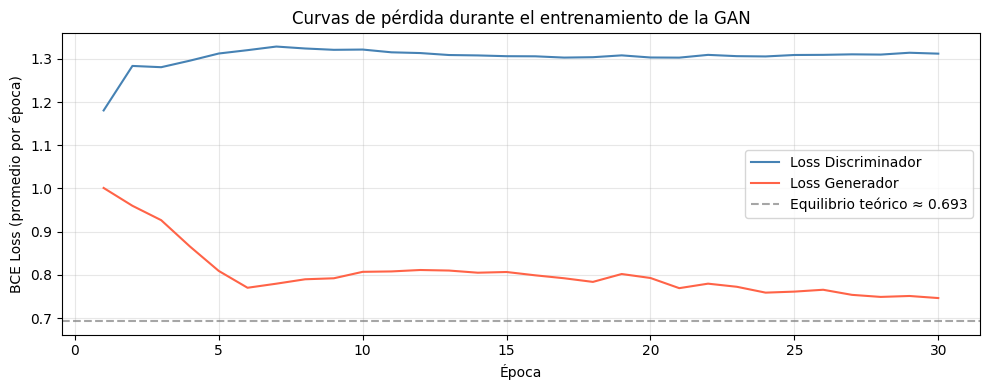


Loss final — Discriminador: 1.3123
Loss final — Generador:     0.7463
Equilibrio teórico (ln 2):  0.6931


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
epocas_eje = range(1, EPOCAS + 1)
ax.plot(epocas_eje, historial_loss_d, label='Loss Discriminador', color='steelblue')
ax.plot(epocas_eje, historial_loss_g, label='Loss Generador',     color='tomato')
ax.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.7,
           label=f'Equilibrio teórico ≈ {np.log(2):.3f}')
ax.set_xlabel('Época')
ax.set_ylabel('BCE Loss (promedio por época)')
ax.set_title('Curvas de pérdida durante el entrenamiento de la GAN')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nLoss final — Discriminador: {historial_loss_d[-1]:.4f}')
print(f'Loss final — Generador:     {historial_loss_g[-1]:.4f}')
print(f'Equilibrio teórico (ln 2):  {np.log(2):.4f}')

### 7.2 Imágenes generadas al final del entrenamiento

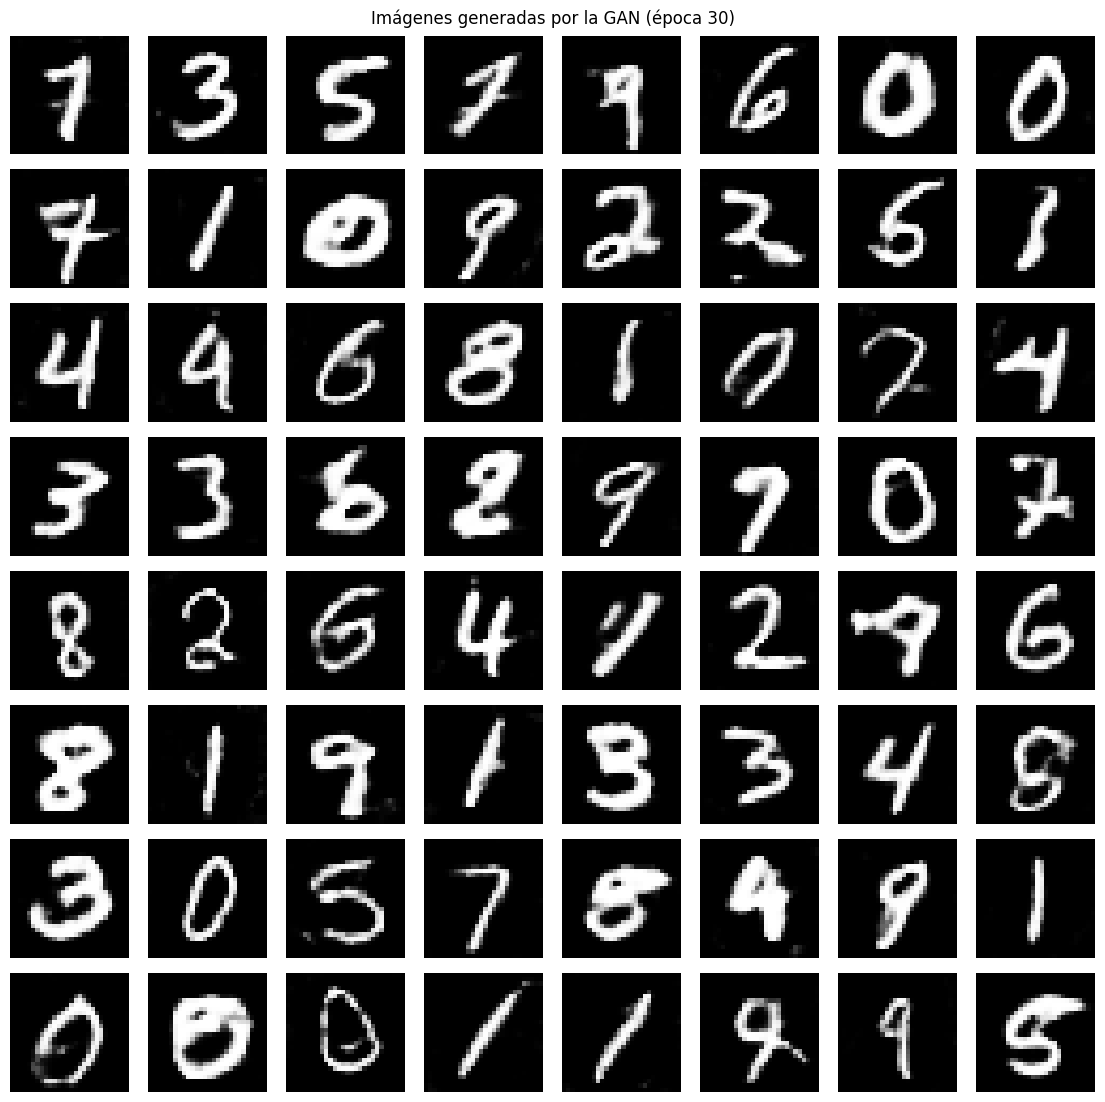

In [8]:
def mostrar_grilla(imagenes, titulo, n_cols=8):
    """Muestra una grilla de imágenes generadas."""
    n = len(imagenes)
    n_filas = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_filas, n_cols,
                             figsize=(n_cols * 1.4, n_filas * 1.4))
    for i, ax in enumerate(axes.flat):
        if i < n:
            # Desnormalizar: [-1, 1] → [0, 1]
            img = (imagenes[i, :, :, 0] + 1.0) / 2.0
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.suptitle(titulo, fontsize=12)
    plt.tight_layout()
    plt.show()


# Generar 64 imágenes nuevas
ruido_nuevo = tf.random.normal([64, DIM_LATENTE])
imgs_finales = generador(ruido_nuevo, training=False).numpy()

mostrar_grilla(imgs_finales,
               f'Imágenes generadas por la GAN (época {EPOCAS})',
               n_cols=8)

### 7.3 Progreso del Generador a lo largo del entrenamiento

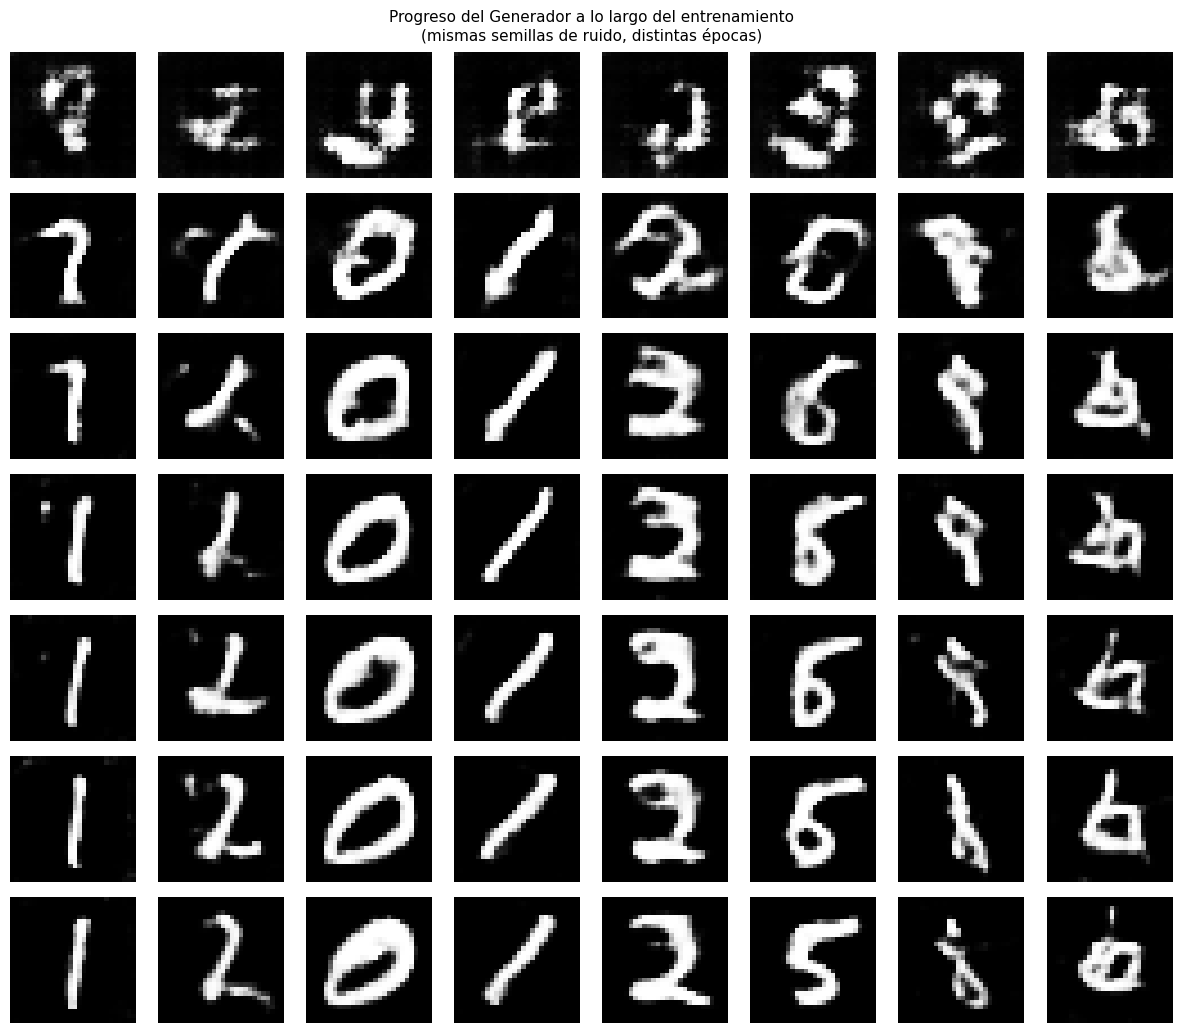

In [9]:
# Mostrar la misma semilla de ruido fijo en distintas épocas
epocas_mostrar = [1, 5, 10, 15, 20, 25, 30]
epocas_mostrar = [e for e in epocas_mostrar if e in imagenes_por_epoca]

fig, axes = plt.subplots(len(epocas_mostrar), 8,
                          figsize=(12, len(epocas_mostrar) * 1.5))

for fila, epoca in enumerate(epocas_mostrar):
    imgs = imagenes_por_epoca[epoca]  # 16 imágenes del ruido fijo
    for col in range(8):
        ax = axes[fila, col] if len(epocas_mostrar) > 1 else axes[col]
        if col < len(imgs):
            img = (imgs[col, :, :, 0] + 1.0) / 2.0
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Época {epoca}', rotation=90,
                          fontsize=9, labelpad=4)

plt.suptitle('Progreso del Generador a lo largo del entrenamiento\n'
             '(mismas semillas de ruido, distintas épocas)',
             fontsize=11)
plt.tight_layout()
plt.show()

### 7.4 Interpolación en el espacio latente

Una propiedad interesante de las GANs es que el espacio latente es continuo. Al interpolar linealmente entre dos vectores de ruido, el Generador produce transiciones suaves entre imágenes.

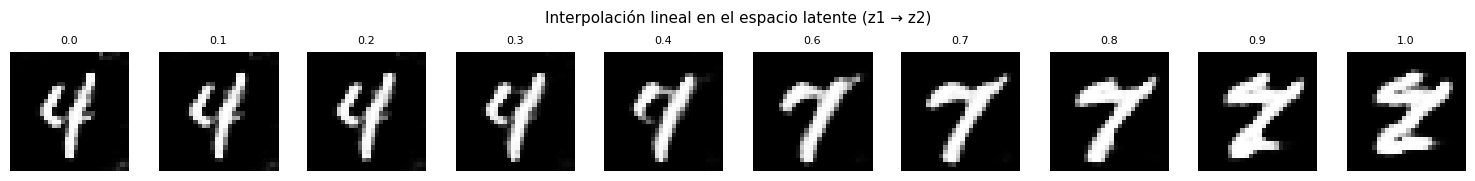

In [10]:
# Dos puntos en el espacio latente
z1 = tf.random.normal([1, DIM_LATENTE], seed=7)
z2 = tf.random.normal([1, DIM_LATENTE], seed=99)

# 10 pasos de interpolación lineal
n_pasos = 10
alphas  = np.linspace(0, 1, n_pasos)
z_interp = tf.stack([(1 - a) * z1 + a * z2 for a in alphas], axis=0)
z_interp = tf.squeeze(z_interp, axis=1)   # (n_pasos, DIM_LATENTE)

imgs_interp = generador(z_interp, training=False).numpy()

fig, axes = plt.subplots(1, n_pasos, figsize=(n_pasos * 1.5, 1.8))
for i, ax in enumerate(axes):
    img = (imgs_interp[i, :, :, 0] + 1.0) / 2.0
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f'{alphas[i]:.1f}', fontsize=8)

plt.suptitle('Interpolación lineal en el espacio latente (z1 → z2)',
             fontsize=11)
plt.tight_layout()
plt.show()

### 7.5 Comparación: imágenes reales vs. generadas

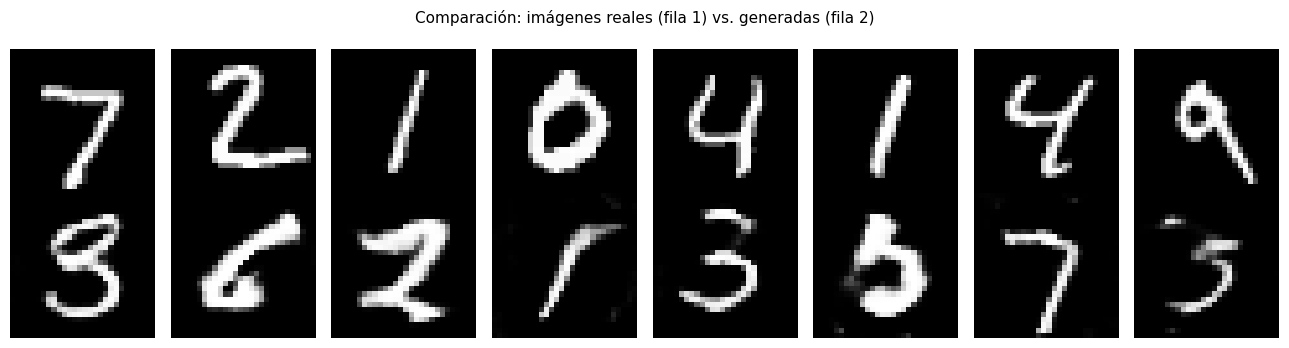

In [11]:
# Muestras reales del dataset de test
(_, _), (x_test_raw, _) = keras.datasets.mnist.load_data()
x_test_norm = x_test_raw[:8].astype('float32') / 255.0

# Imágenes generadas
ruido_comp = tf.random.normal([8, DIM_LATENTE])
imgs_gen_comp = (generador(ruido_comp, training=False).numpy()[:, :, :, 0] + 1.0) / 2.0

fig, axes = plt.subplots(2, 8, figsize=(13, 3.5))
for col in range(8):
    axes[0, col].imshow(x_test_norm[col], cmap='gray', vmin=0, vmax=1)
    axes[0, col].axis('off')
    axes[1, col].imshow(imgs_gen_comp[col], cmap='gray', vmin=0, vmax=1)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Reales', fontsize=10, rotation=90)
axes[1, 0].set_ylabel('Generadas', fontsize=10, rotation=90)

plt.suptitle('Comparación: imágenes reales (fila 1) vs. generadas (fila 2)',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. Análisis de resultados

### Comportamiento de las curvas de pérdida

El **equilibrio teórico** de una GAN ocurre cuando ambas pérdidas convergen a `ln(2) ≈ 0.693`. En ese punto el Discriminador no puede distinguir reales de falsas (responde 0.5 para todo). En la práctica:

- La **pérdida del Discriminador** tiende a mantenerse baja al principio (cuando el Generador produce imágenes de baja calidad, el Discriminador las distingue fácilmente). Conforme el Generador mejora, la pérdida del Discriminador sube hacia el equilibrio.
- La **pérdida del Generador** suele comenzar alta y decrecer a medida que aprende a engañar al Discriminador.
- **Oscilaciones** son esperables: el entrenamiento adversarial es inherentemente inestable.

### Calidad de las imágenes generadas

Con 30 épocas sobre MNIST, el Generador ya produce dígitos reconocibles aunque con cierta borrosidad. Las características observables:

- Las imágenes presentan **estructura global** de dígito (curvas, trazos verticales, etc.).
- **Bordes difusos** — efecto esperado con pocas épocas; más épocas o arquitecturas más profundas mejorarían la nitidez.
- El Generador tiende a generar ciertos dígitos con más frecuencia (**mode collapse parcial**).

### Dificultades encontradas

| Dificultad | Descripción | Solución aplicada |
|---|---|---|
| Inestabilidad de pérdidas | Oscilaciones bruscas, especialmente en las primeras épocas | `beta_1=0.5` en Adam, `BatchNorm` en G, `Dropout` en D |
| Mode collapse | El Generador produce pocos tipos de imágenes | Arquitectura moderadamente profunda, LR bajo |
| Velocidad | 30 épocas toman ~5–8 min en CPU | Compilación con `@tf.function`, prefetch del dataset |

### Posibles mejoras

1. **Más épocas** (50–100): las imágenes ganarían definición y variedad.
2. **DCGAN más profundo**: añadir más bloques de convolución con más filtros.
3. **Conditional GAN (CGAN)**: condicionar la generación por dígito (etiqueta) para controlar qué número genera el modelo.
4. **Wasserstein GAN (WGAN)**: función de pérdida más estable que BCE, reduce el riesgo de mode collapse.
5. **Spectral Normalization**: estabiliza el entrenamiento del Discriminador.

### Aprendizajes técnicos

- La dinámica adversarial es mucho más delicada que el entrenamiento supervisado estándar: los dos modelos deben avanzar a un ritmo similar para evitar que uno domine al otro.
- El preprocesamiento al rango **[-1, 1]** es crítico para la compatibilidad con la activación `tanh` del Generador.
- El uso de **`GradientTape`** separados para G y D es fundamental para actualizar correctamente solo los parámetros de cada modelo en su turno.
- La interpolación en el espacio latente demuestra que el Generador aprende una representación continua y estructurada, no solo memorización.